## Carga del modelo clásico y features de test

Recupera el SVM, scaler y lista de features guardados, y prepara las features de test alineadas a esa lista. Deja `Xte`/`y_test` listos para evaluar el pipeline híbrido.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

FEATURES_DIR = Path('../results/features')
MODEL_DIR    = Path('../results/models')
FIG_DIR      = Path('../results/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# cargar modelo SVM y scaler
svm      = joblib.load(MODEL_DIR / 'svm_clasico.pkl')
scaler   = joblib.load(MODEL_DIR / 'scaler_clasico.pkl')
features = joblib.load(MODEL_DIR / 'features_clasico.pkl')

# cargar features de test
df_test  = pd.read_csv(FEATURES_DIR / 'features_test.csv')
X_test   = df_test[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_test   = df_test['clase'].values
Xte      = scaler.transform(X_test)
clases   = sorted(np.unique(y_test))

print(f'Test: {Xte.shape}')
print(f'Clases: {clases}')

Test: (7096, 113)
Clases: ['battery', 'cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'textile', 'trash']


## Umbral de confianza del SVM

Calcula las probabilidades del SVM y separa las imágenes según su confianza máxima frente al umbral θ=0.60. Las de alta confianza se resolverán con el SVM; las de baja pasarán al verificador CNN. El histograma muestra la distribución de confianza y dónde cae el umbral.

Imágenes con confianza >= 0.6: 4412 (62.2%)
Imágenes con confianza <  0.6: 2684 (37.8%)

Accuracy SVM solo: 0.693


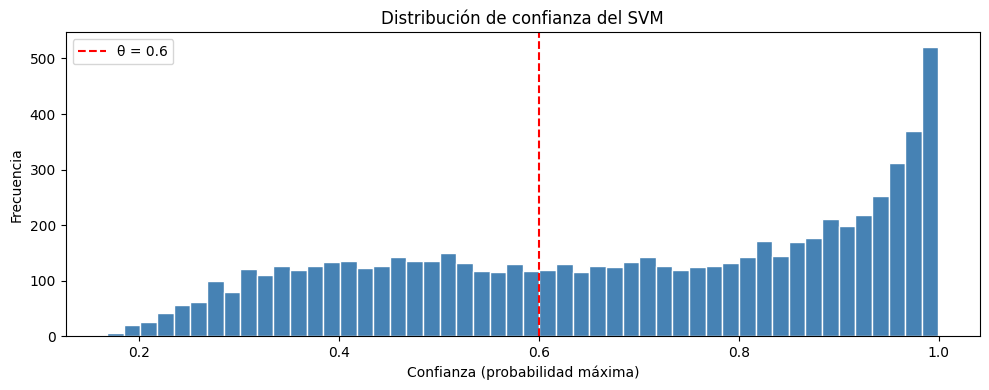

In [2]:
THETA = 0.60  # umbral de confianza

proba        = svm.predict_proba(Xte)
confianza    = proba.max(axis=1)
pred_svm     = svm.predict(Xte)

# separar imágenes por confianza
mask_alta    = confianza >= THETA
mask_baja    = confianza < THETA

print(f'Imágenes con confianza >= {THETA}: {mask_alta.sum()} ({mask_alta.mean():.1%})')
print(f'Imágenes con confianza <  {THETA}: {mask_baja.sum()} ({mask_baja.mean():.1%})')
print(f'\nAccuracy SVM solo: {accuracy_score(y_test, pred_svm):.3f}')

# distribución de confianza
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(confianza, bins=50, color='steelblue', edgecolor='white')
ax.axvline(THETA, color='red', linestyle='--', label=f'θ = {THETA}')
ax.set_title('Distribución de confianza del SVM')
ax.set_xlabel('Confianza (probabilidad máxima)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '06_distribucion_confianza_svm.png', dpi=150)
plt.show()

## Verificador CNN (MobileNetV2 transfer learning)

Construye el verificador: MobileNetV2 preentrenada en ImageNet con base congelada, más cabeza de pooling, dropout y softmax sobre las 9 clases. Se entrena con los generadores de train/val y se guarda como `cnn_verificador.h5`.

In [3]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

PROCESSED_DIR = Path('../data/processed')
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 10
N_CLASES      = len(clases)

# generadores
datagen_train = ImageDataGenerator(rescale=1./255)
datagen_val   = ImageDataGenerator(rescale=1./255)

gen_train = datagen_train.flow_from_directory(
    PROCESSED_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
gen_val = datagen_val.flow_from_directory(
    PROCESSED_DIR / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# modelo
base    = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base.trainable = False

x       = base.output
x       = GlobalAveragePooling2D()(x)
x       = Dropout(0.3)(x)
output  = Dense(N_CLASES, activation='softmax')(x)

modelo_cnn = Model(inputs=base.input, outputs=output)
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = modelo_cnn.fit(
    gen_train,
    validation_data=gen_val,
    epochs=EPOCHS
)

modelo_cnn.save(MODEL_DIR / 'cnn_verificador.h5')
print('CNN guardada.')

Found 6750 images belonging to 9 classes.
Found 7095 images belonging to 9 classes.
Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.7412 - loss: 0.7903 - val_accuracy: 0.8544 - val_loss: 0.4519
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 238s 1s/step - accuracy: 0.8784 - loss: 0.3704 - val_accuracy: 0.8767 - val_loss: 0.3803
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9096 - loss: 0.2809 - val_accuracy: 0.8851 - val_loss: 0.3463
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9241 - loss: 0.2398 - val_accuracy: 0.8902 - val_loss: 0.3366
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.9246 - loss: 0.2168 - val_accuracy: 0.8939 - val_loss: 0.3222
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 202s 959ms/step - accuracy: 0.9384 - loss: 0.1959 - val_accuracy: 0.8951 - val_loss: 0.3107
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 201s 953ms/step - accuracy: 0.9401 - loss: 0.1812 - val_accuracy: 0.8943 - val_loss: 0.3074
Epoch 8

CNN guardada.


## Reconstrucción de rutas de test

Mapea cada fila del CSV de test a su archivo de imagen en disco, necesario porque la CNN opera sobre el píxel y no sobre las features tabulares. Verifica cuántas rutas se resolvieron.

In [ ]:
def reconstruir_ruta(nombre_archivo, clase):
    ruta = PROCESSED_DIR / 'test' / clase / nombre_archivo
    if ruta.exists():
        return ruta
    return None

rutas_test = [reconstruir_ruta(row['archivo'], row['clase']) 
              for _, row in df_test.iterrows()]

# verificar cuántas rutas encontró
encontradas = sum(1 for r in rutas_test if r is not None)
print(f'Rutas encontradas: {encontradas}/{len(rutas_test)}')

## Pipeline híbrido SVM + CNN

Enrutamiento por confianza: si el SVM supera θ resuelve él; si no, la imagen se delega a la CNN. Registra la fuente de cada predicción y compara la accuracy del SVM solo contra la del híbrido.

In [7]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image

cnn = load_model(MODEL_DIR / 'cnn_verificador.h5')

idx_to_clase = {v: k for k, v in gen_val.class_indices.items()}

def predecir_cnn(img_path):
    img  = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr  = keras_image.img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)
    prob = cnn.predict(arr, verbose=0)
    return idx_to_clase[np.argmax(prob)]

pred_hibrido = []
fuente       = []

for i, (ruta, conf, pred_s) in enumerate(zip(rutas_test, confianza, pred_svm)):
    if conf >= THETA:
        pred_hibrido.append(pred_s)
        fuente.append('SVM')
    else:
        pred_hibrido.append(predecir_cnn(ruta))
        fuente.append('CNN')

pred_hibrido = np.array(pred_hibrido)

print(f'Resueltos por SVM : {fuente.count("SVM")} ({fuente.count("SVM")/len(fuente):.1%})')
print(f'Resueltos por CNN : {fuente.count("CNN")} ({fuente.count("CNN")/len(fuente):.1%})')
print(f'\nAccuracy SVM solo  : {accuracy_score(y_test, pred_svm):.3f}')
print(f'Accuracy híbrido   : {accuracy_score(y_test, pred_hibrido):.3f}')

Resueltos por SVM : 4412 (62.2%)
Resueltos por CNN : 2684 (37.8%)

Accuracy SVM solo  : 0.693
Accuracy híbrido   : 0.842


## Comparación visual SVM vs híbrido

Matrices de confusión lado a lado (SVM solo vs híbrido) para visualizar en qué clases el verificador CNN corrige errores del SVM.

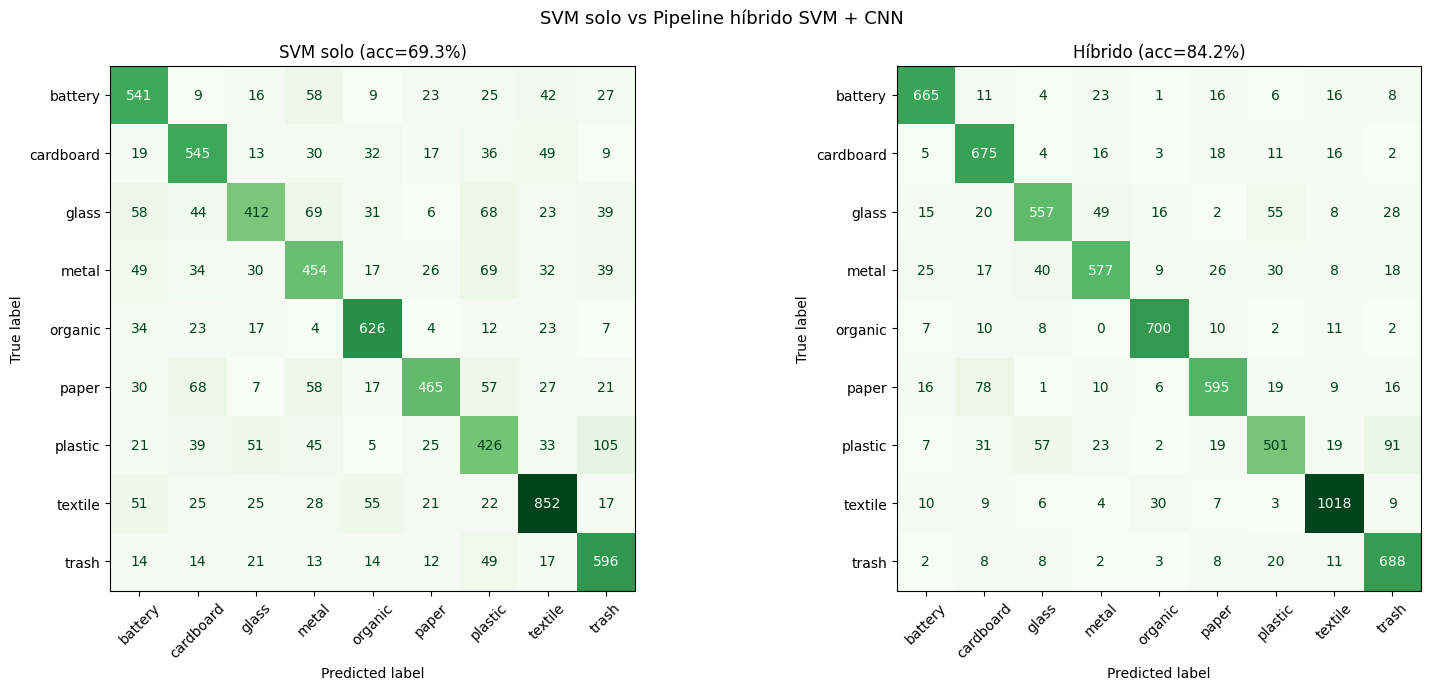

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (pred, titulo) in zip(axes, [
    (pred_svm,     f'SVM solo (acc={accuracy_score(y_test, pred_svm):.1%})'),
    (pred_hibrido, f'Híbrido (acc={accuracy_score(y_test, pred_hibrido):.1%})')
]):
    cm = confusion_matrix(y_test, pred, labels=clases)
    ConfusionMatrixDisplay(cm, display_labels=clases).plot(ax=ax, cmap='Greens', colorbar=False, xticks_rotation=45)
    ax.set_title(titulo)

plt.suptitle('SVM solo vs Pipeline híbrido SVM + CNN', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_comparacion_svm_vs_hibrido.png', dpi=150)
plt.show()

## Persistencia de resultados

Guarda predicciones, etiquetas reales, fuente por imagen, confianzas y el historial de entrenamiento de la CNN para los análisis posteriores.

In [10]:
import joblib

joblib.dump(pred_svm,      MODEL_DIR / 'pred_svm.pkl')
joblib.dump(pred_hibrido,  MODEL_DIR / 'pred_hibrido.pkl')
joblib.dump(y_test,        MODEL_DIR / 'y_test.pkl')
joblib.dump(fuente,        MODEL_DIR / 'fuente.pkl')
joblib.dump(confianza,     MODEL_DIR / 'confianza.pkl')
joblib.dump(history.history, MODEL_DIR / 'cnn_history.pkl')


print('Variables guardadas.')

Variables guardadas.
